In [120]:
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

# download
import google.colab.files as files

# data
import numpy as np
import pandas as pd

# charts
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns

# models and metrics
import keras
import keras.layers as layers
from keras.utils import to_categorical
keras.utils.set_random_seed(42)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# import e analisi del dataset

In [121]:
# fetch dataset
dry_bean = fetch_ucirepo(id=602)

# data (as pandas dataframes)
X = dry_bean.data.features
y = dry_bean.data.targets

# total dataset
dry_bean = pd.concat([X, y], axis=1)

# number of rows and columns
print(f"dataset with {dry_bean.shape[0]} rows and {dry_bean.shape[1]} columns")

dataset with 13611 rows and 17 columns


## controllo del tipo delle features

In [122]:
X.dtypes

,0
Area,int64
Perimeter,float64
MajorAxisLength,float64
MinorAxisLength,float64
AspectRatio,float64
Eccentricity,float64
ConvexArea,int64
EquivDiameter,float64
Extent,float64
Solidity,float64


## controllo della distribuzione delle features

In [123]:
# print some stats related to the dataset
X.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRatio,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,Roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860154,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


## controllo presenza di valori NaN o mancanti

In [124]:
# counting the number of NaN or None value in the dataset for each column
n_null = X.isnull().sum()
print(n_null)

Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRatio        0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
Roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
dtype: int64


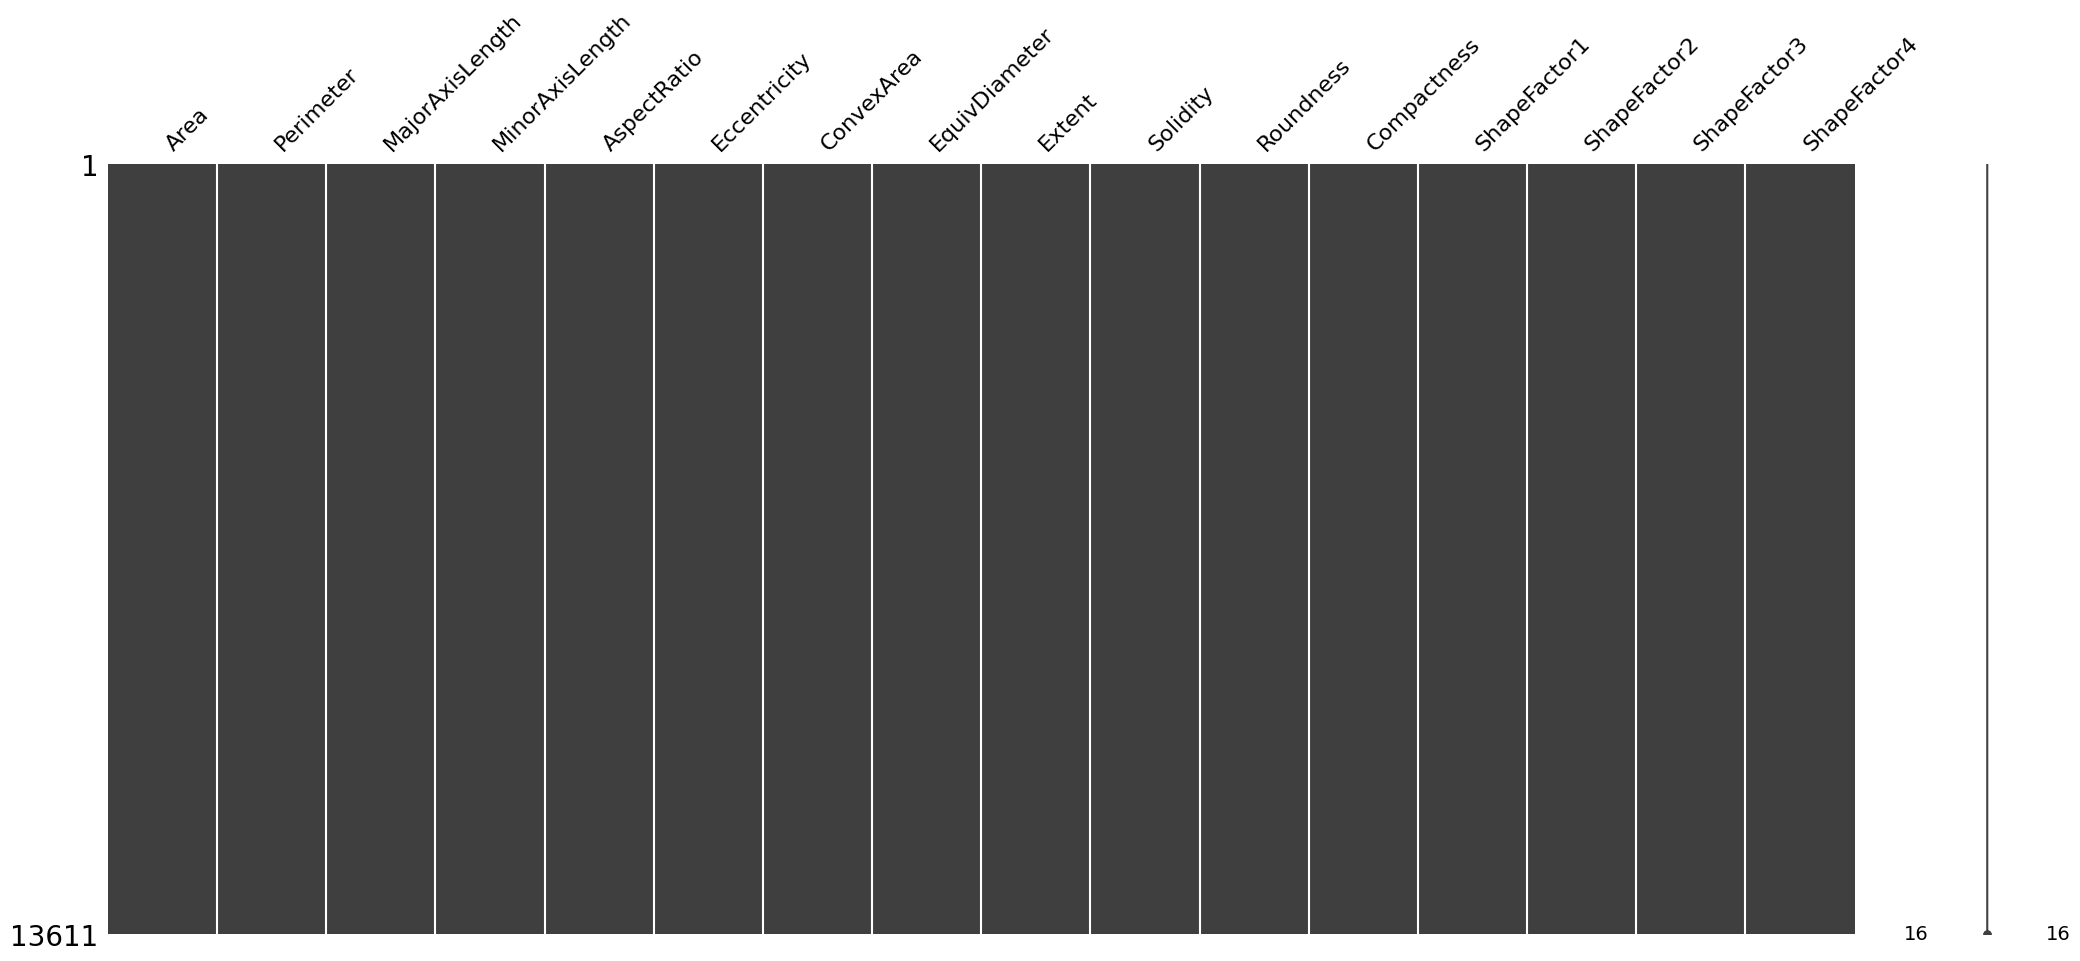

In [125]:
# visualization of row with missing values
msno.matrix(X)
plt.show()

## distribuzione delle classi target

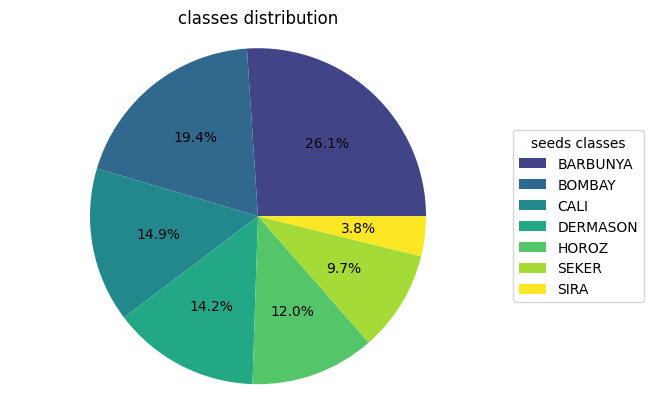

In [126]:
# creations of labels, classes numeric data and colors needed
# to do the chart and the legend
labels = np.unique(y)
y_data = y.value_counts()
colors = plt.cm.viridis(np.linspace(0.2, 1, len(labels)))

# creation of the plot
fig, ax = plt.subplots()
ax.pie(y_data, colors=colors, autopct='%1.1f%%')
ax.legend(labels=labels, title="seeds classes", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

# set the title
ax.set_title("classes distribution")

# showing
ax.axis('equal')
plt.show()

## data distribution

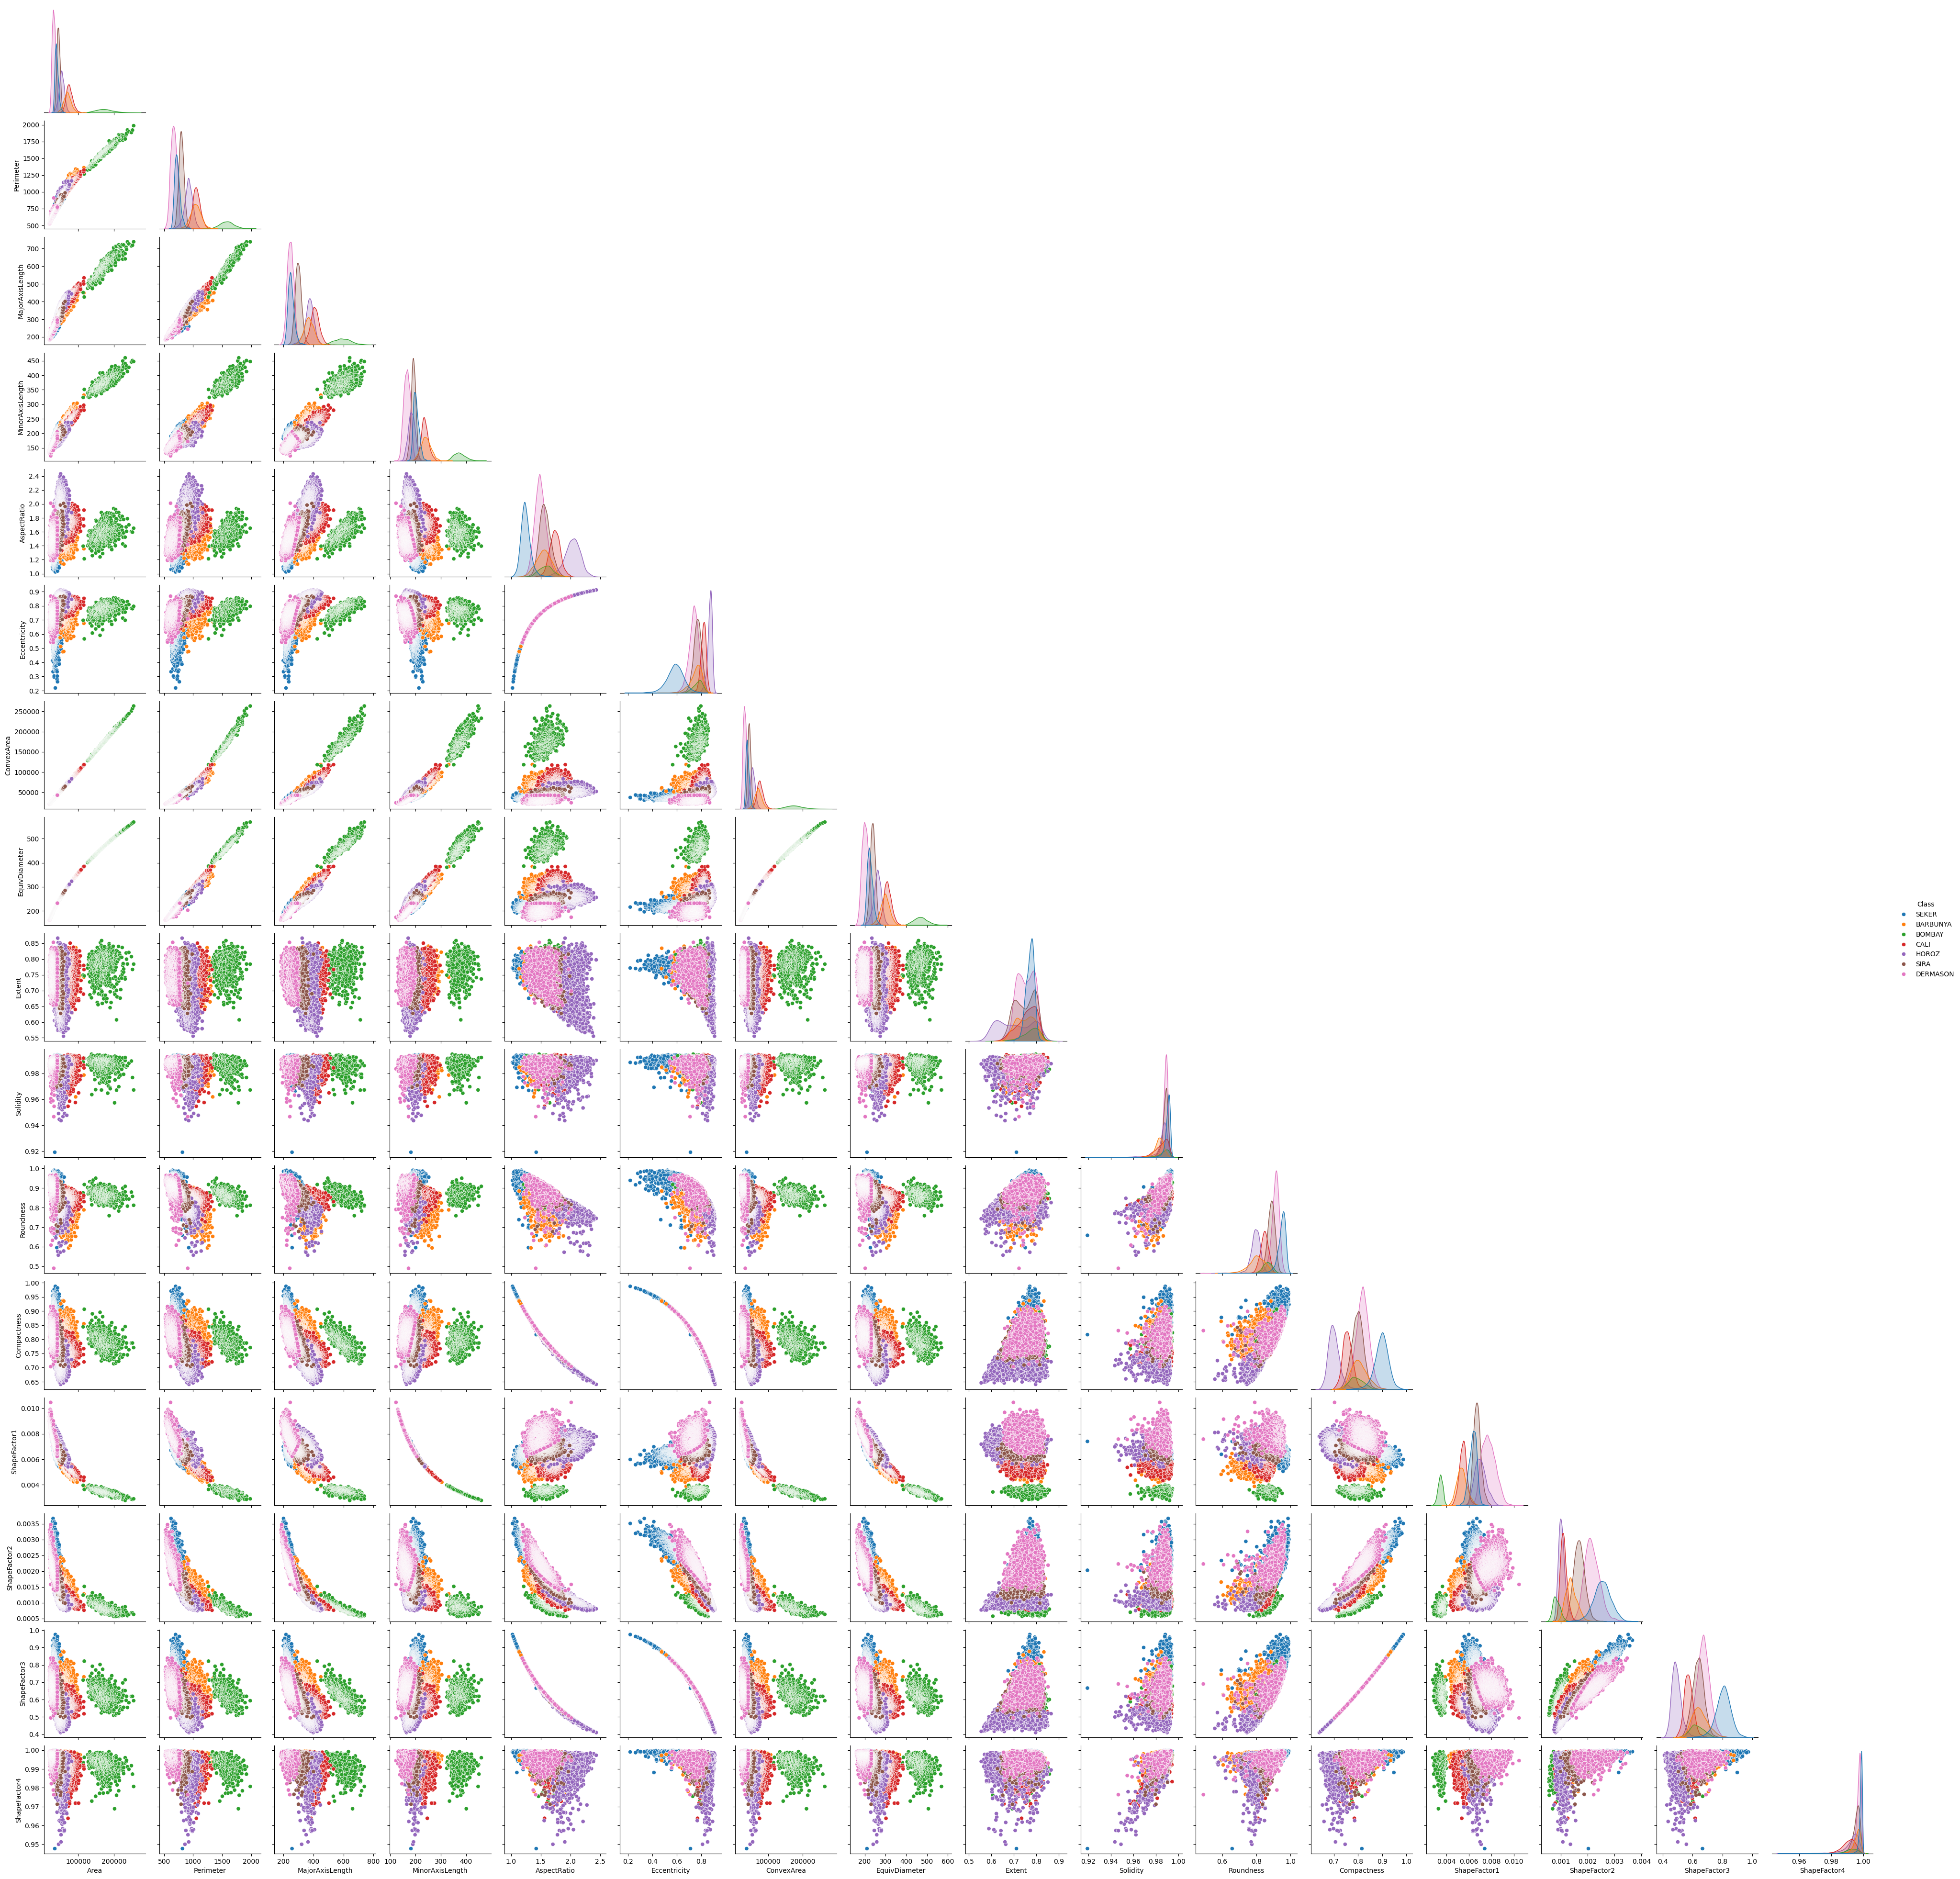

In [127]:
sns.pairplot(data=dry_bean, hue='Class', corner=True)
plt.show()

## outliers

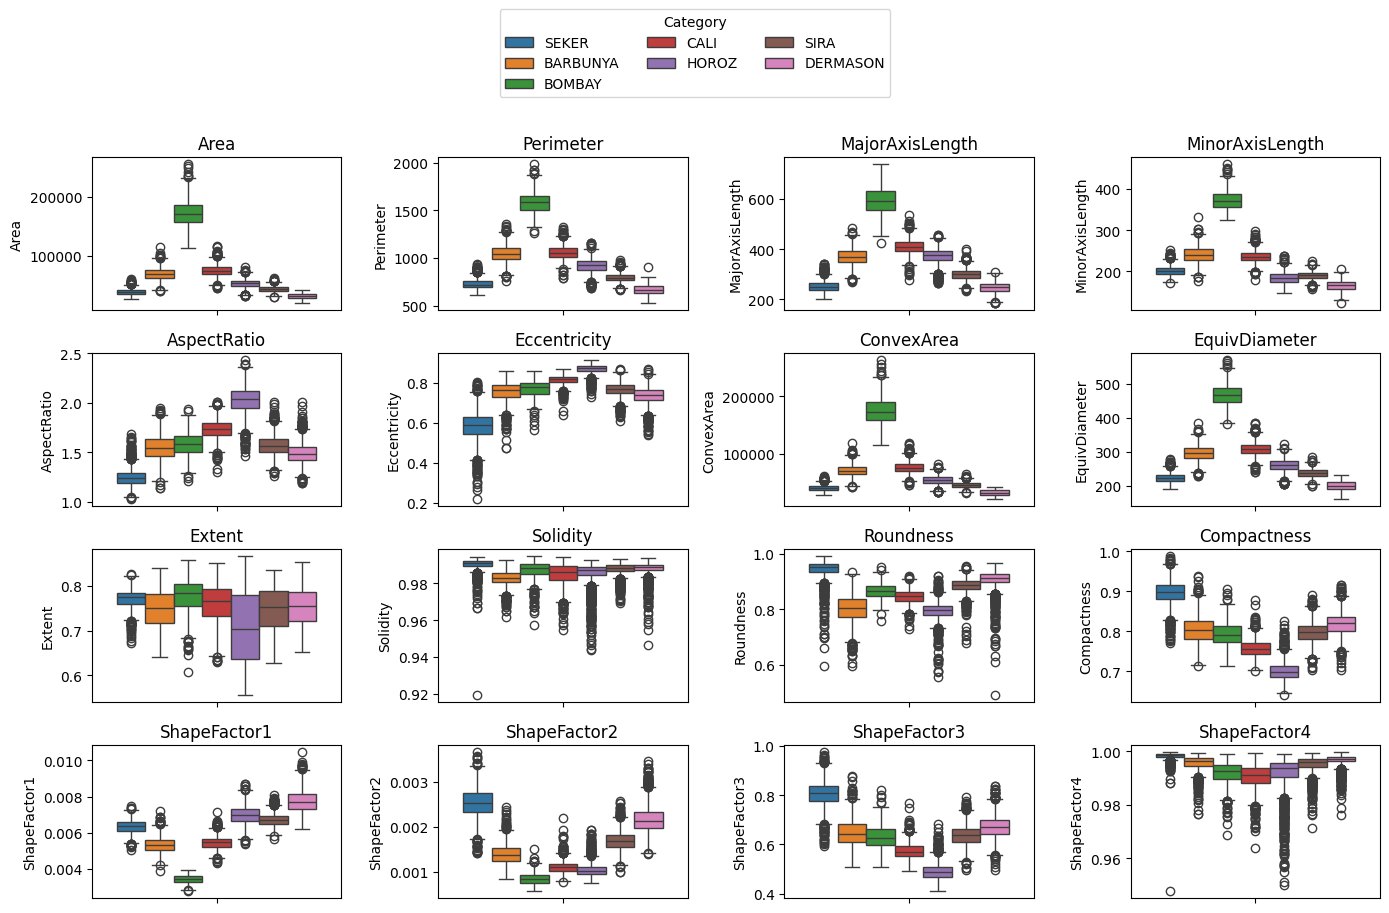

In [147]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(14, 8))
axes = axes.flatten()

#boxplot for each feature
handles, labels = None, None
for i, col in enumerate(dry_bean.columns[:-1]):
    boxplot = sns.boxplot(data=dry_bean, y=dry_bean[col], ax=axes[i], hue='Class')
    axes[i].set_title(f'{col}')

    if i == 0:
        handles, labels = boxplot.get_legend_handles_labels()

    axes[i].legend_.remove()

# removing empty subplot
fig.legend(handles, labels, title='Category', loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=3)

plt.tight_layout()
#plt.savefig('outlier.png', bbox_inches='tight')
plt.show()

#download
#files.download('outlier.png')

## correlazione delle features

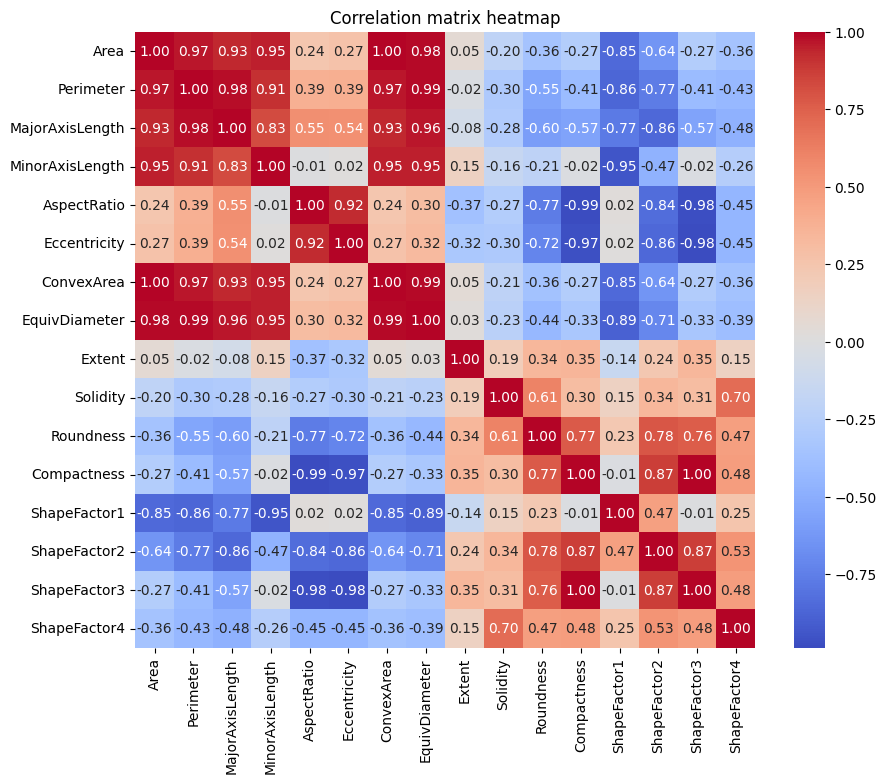

In [129]:
# generation of the correlation matrix
correlation_matrix = X.corr(numeric_only=True)

# generation of the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation matrix heatmap')

plt.show()

## data normalization

In [130]:
# target encoding
label_encoder = LabelEncoder()
y_numerical = label_encoder.fit_transform(y)
y_categorical = to_categorical(y_numerical)

# splitting in train and test set
x_train, x_test, y_train, y_test = train_test_split(X, y_categorical, test_size=0.2, random_state=42)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

# dataset normalization
normalization_constant = x_train.max()
x_train = x_train / normalization_constant
x_val = x_val / normalization_constant
x_test = x_test / normalization_constant


print(f"x_train shape: {x_train.shape}")
print(f"x_val shape: {x_val.shape}")
print(f"x_test shape: {x_test.shape}")

x_train shape: (8710, 16)
x_val shape: (2178, 16)
x_test shape: (2723, 16)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


# model definition

In [131]:
model = keras.Sequential(
  [
    keras.Input(shape=(16,), name="input"),
    keras.layers.Dense(64, activation="relu",
                       name="hidden_layer_1"),
    keras.layers.Dense(16, activation="relu",
                       name="hidden_layer_2"),
    keras.layers.Dense(7, activation='softmax',
                       name="output")
  ]
)

model.build()

model.compile(
  optimizer=keras.optimizers.Adam(),
  loss=keras.losses.CategoricalFocalCrossentropy(),
  metrics=[keras.metrics.CategoricalAccuracy()]
)

model.summary()
history = model.fit(x_train, y_train, epochs=10, batch_size=32, validation_data=(x_val, y_val))

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 7)              │           119 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,247 (8.78 KB)

 Trainable params: 2,247 (8.78 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - categorical_accuracy: 0.2338 - loss: 0.3061 - val_categorical_accuracy: 0.6469 - val_loss: 0.1395
Epoch 2/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - categorical_accuracy: 0.7605 - loss: 0.1043 - val_categorical_accuracy: 0.8687 - val_loss: 0.0540
Epoch 3/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - categorical_accuracy: 0.8671 - loss: 0.0474 - val_categorical_accuracy: 0.8719 - val_loss: 0.0388
Epoch 4/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - categorical_accuracy: 0.8723 - loss: 0.0367 - val_categorical_accuracy: 0.8728 - val_loss: 0.0347
Epoch 5/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - categorical_accuracy: 0.8747 - loss: 0.0335 - val_categorical_accuracy: 0.8714 - val_loss: 0.0332
Epoch 6/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - categorical_accuracy: 0.8769 - loss: 0.0321 - val_categorical_accuracy: 0.8751 - val_loss: 0.0325
Epoch 7/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - categorical_accuracy: 0.8795 - lo

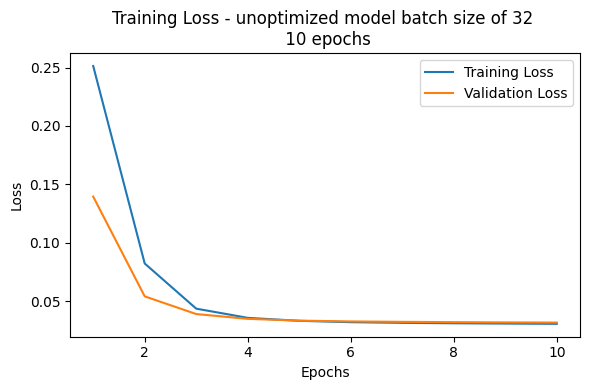

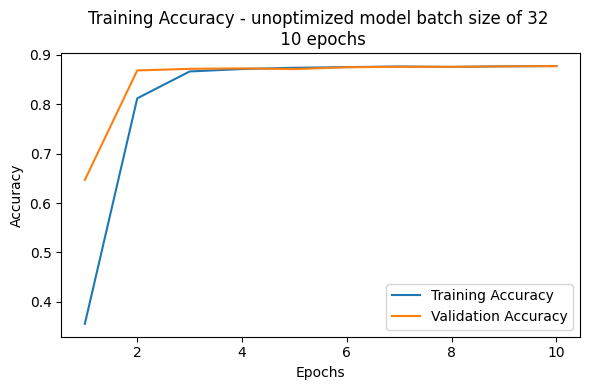

In [132]:
def plot_history(history, title):
  # loss plot
  fig_loss, ax_loss = plt.subplots(figsize=(6, 4))
  epochs = range(1, len(history.history['loss']) + 1)
  ax_loss.plot(epochs, history.history['loss'], label='Training Loss')
  ax_loss.plot(epochs, history.history['val_loss'], label='Validation Loss')
  ax_loss.set_title('Training Loss - ' + title)
  ax_loss.set_xlabel('Epochs')
  ax_loss.set_ylabel('Loss')
  ax_loss.legend()
  plt.tight_layout()
  #plt.savefig(title.replace(" ", "_") + '_loss.png')
  #files.download(title.replace(" ", "_") + '_loss.png')
  plt.show()

  # accuracy plot
  fig_acc, ax_acc = plt.subplots(figsize=(6, 4))
  ax_acc.plot(epochs, history.history['categorical_accuracy'], label='Training Accuracy')
  ax_acc.plot(epochs, history.history['val_categorical_accuracy'], label='Validation Accuracy')
  ax_acc.set_title('Training Accuracy - ' + title)
  ax_acc.set_xlabel('Epochs')
  ax_acc.set_ylabel('Accuracy')
  ax_acc.legend()
  plt.tight_layout()
  #plt.savefig(title.replace(" ", "_") + '_accuracy.png')
  #files.download(title.replace(" ", "_") + '_accuracy.png')
  plt.show()

plot_history(history, "unoptimized model batch size of 32 \n 10 epochs")

## first model evaluation

In [133]:
model = keras.Sequential(
  [
    keras.Input(shape=(16,), name="input"),
    keras.layers.Dense(64, activation="relu",
                       name="hidden_layer_1"),
    keras.layers.Dense(16, activation="relu",
                       name="hidden_layer_2"),
    keras.layers.Dense(7, activation='softmax',
                       name="output")
  ]
)

model.build()

model.compile(
  optimizer=keras.optimizers.Adam(),
  loss=keras.losses.CategoricalFocalCrossentropy(),
  metrics=[keras.metrics.CategoricalAccuracy()]
)

model.summary()
history_initial = model.fit(pd.concat([x_train, x_val]), np.concatenate([y_train, y_val]), epochs=10, batch_size=32)

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 7)              │           119 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,247 (8.78 KB)

 Trainable params: 2,247 (8.78 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
341/341 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - categorical_accuracy: 0.2486 - loss: 0.3125
Epoch 2/10
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - categorical_accuracy: 0.7413 - loss: 0.1027
Epoch 3/10
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - categorical_accuracy: 0.8651 - loss: 0.0409
Epoch 4/10
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - categorical_accuracy: 0.8754 - loss: 0.0331
Epoch 5/10
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - categorical_accuracy: 0.8800 - loss: 0.0307
Epoch 6/10
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - categorical_accuracy: 0.8811 - loss: 0.0298
Epoch 7/10
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - categorical_accuracy: 0.8824 - loss: 0.0292
Epoch 8/10
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - categorical_accuracy: 0.8839 - loss: 0.0289
Epoch 9/10
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - categorical_accuracy: 0.8846 - loss: 0.0287
Epoch 10/10
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - categorical_accuracy: 0.8852 - loss: 0.0285


86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


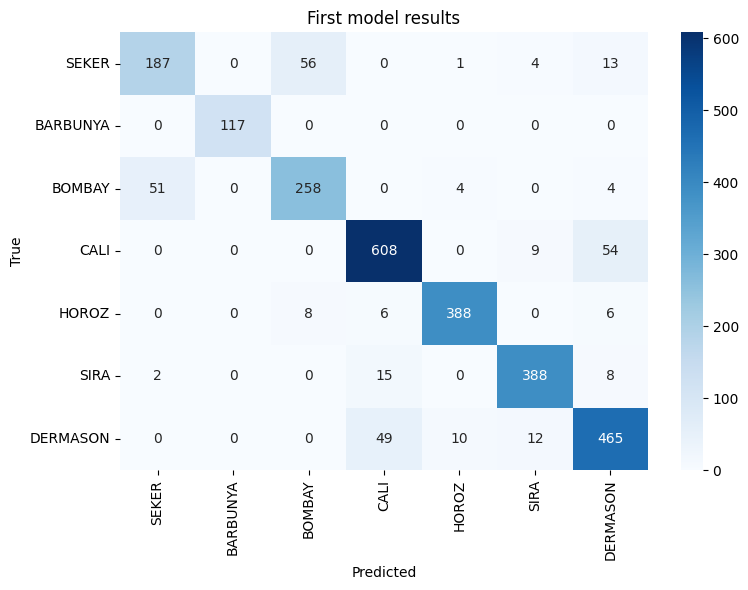

In [134]:
y_pred_initial = model.predict(x_test)
y_pred_classes_initial = np.argmax(y_pred_initial, axis=1)
y_true_classes_initial = np.argmax(y_test, axis=1)

# generate confusion matrix
cm = confusion_matrix(y_true_classes_initial, y_pred_classes_initial)

plt.figure(figsize=(8, 6))

# add labels
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('First model results')
plt.xticks(rotation=90)
plt.tight_layout()
#plt.savefig('first_model_results.png')
#files.download('first_model_results.png')

plt.show()

In [135]:
# generate classification report
report_initial = classification_report(y_true_classes_initial, y_pred_classes_initial)

print("Classification Report:")
print(report_initial)

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.72      0.75       261
           1       1.00      1.00      1.00       117
           2       0.80      0.81      0.81       317
           3       0.90      0.91      0.90       671
           4       0.96      0.95      0.96       408
           5       0.94      0.94      0.94       413
           6       0.85      0.87      0.86       536

    accuracy                           0.89      2723
   macro avg       0.89      0.88      0.89      2723
weighted avg       0.89      0.89      0.89      2723



### analisi dell'errore

In [136]:
cl_1 = dry_bean[(dry_bean['Class'] == 'BOMBAY') | (dry_bean['Class'] == 'SEKER')]
cl_1.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRatio,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,Roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,2549.000000,2549.000000,2549.000000,2549.000000,2549.000000,2549.000000,2549.000000,2549.000000,2549.000000,2549.000000,2549.000000,2549.000000,2549.000000,2549.000000,2549.000000,2549.000000
mean,67241.504904,903.368064,321.300189,237.223576,1.314885,0.622818,68027.014515,274.914835,0.772675,0.989644,0.928107,0.875498,0.005742,0.002193,0.769116,0.997043
std,55112.827728,352.821129,141.191579,71.068108,0.164732,0.100025,55924.882300,100.201375,0.024366,0.003815,0.044860,0.051180,0.001209,0.000746,0.087259,0.003578
min,28395.000000,610.291000,200.524796,171.210559,1.024868,0.218951,28715.000000,190.141097,0.607021,0.919246,0.595048,0.713613,0.002778,0.000564,0.509244,0.947687
25%,37187.000000,700.716000,240.677011,195.382216,1.204746,0.557688,37541.000000,217.595862,0.759127,0.988843,0.906043,0.852377,0.005782,0.002031,0.726546,0.997030
50%,40841.000000,737.070000,255.221723,204.085532,1.259477,0.607943,41230.000000,228.035910,0.775011,0.990594,0.944501,0.890094,0.006249,0.002437,0.792268,0.998408
75%,48324.000000,813.192000,285.480588,220.511271,1.372592,0.684994,48785.000000,248.048438,0.787361,0.991790,0.960007,0.910297,0.006525,0.002693,0.828640,0.998934
max,254616.000000,1985.370000,738.860154,460.198497,1.933856,0.855924,263261.000000,569.374358,0.858420,0.994677,0.990685,0.987303,0.007474,0.003665,0.974767,0.999733


In [137]:
cl_2 = dry_bean[(dry_bean['Class'] == 'CALI') | (dry_bean['Class'] == 'DERMASON')]
cl_2.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRatio,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,Roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,5176.000000,5176.000000,5176.000000,5176.000000,5176.000000,5176.000000,5176.000000,5176.000000,5176.000000,5176.000000,5176.000000,5176.000000,5176.000000,5176.000000,5176.000000,5176.000000
mean,45792.162481,788.789972,297.870239,187.925876,1.567056,0.761250,46414.550039,235.647857,0.754843,0.987217,0.888533,0.799457,0.007032,0.001829,0.640581,0.994920
std,21201.034742,190.824993,79.345737,35.421032,0.147512,0.050929,21566.705377,52.678418,0.039059,0.004334,0.040015,0.038075,0.001191,0.000548,0.060709,0.004167
min,20420.000000,524.736000,183.601165,122.512653,1.188088,0.539964,20684.000000,161.243764,0.629406,0.946634,0.489618,0.701215,0.004328,0.000762,0.491702,0.963780
25%,30131.750000,645.500500,238.872038,160.771199,1.454370,0.726106,30503.000000,195.869690,0.724134,0.986174,0.859414,0.768222,0.005707,0.001200,0.590165,0.993183
50%,35242.500000,699.055500,259.798861,174.135780,1.540445,0.760649,35673.500000,211.830462,0.758040,0.988376,0.898498,0.804498,0.007332,0.001980,0.647216,0.996507
75%,68291.250000,1006.879500,386.639901,225.374644,1.681951,0.804060,69286.000000,294.874753,0.787567,0.989809,0.918706,0.827843,0.007944,0.002234,0.685323,0.997800
max,116272.000000,1326.583000,534.484404,296.898826,2.010000,0.867457,118144.000000,384.762405,0.852841,0.994378,0.966603,0.915760,0.010451,0.003470,0.838616,0.999709


## model with hyperparameters

In [138]:
model = keras.Sequential(
  [
    keras.Input(shape=(16,), name="input"),
    keras.layers.Dense(64, activation="relu",
                       name="hidden_layer_1"),
    keras.layers.Dense(16, activation="relu",
                       name="hidden_layer_2"),
    keras.layers.Dense(7, activation='softmax',
                       name="output")
  ]
)

model.build()

model.compile(
  optimizer=keras.optimizers.Adam(),
  loss=keras.losses.CategoricalFocalCrossentropy(),
  metrics=[keras.metrics.CategoricalAccuracy()]
)

model.summary()
history_batch = model.fit(x_train, y_train, epochs=50, batch_size=128, validation_data=(x_val, y_val))

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 7)              │           119 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,247 (8.78 KB)

 Trainable params: 2,247 (8.78 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - categorical_accuracy: 0.1699 - loss: 0.3638 - val_categorical_accuracy: 0.2452 - val_loss: 0.3052
Epoch 2/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - categorical_accuracy: 0.2775 - loss: 0.2923 - val_categorical_accuracy: 0.2984 - val_loss: 0.2550
Epoch 3/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - categorical_accuracy: 0.3878 - loss: 0.2363 - val_categorical_accuracy: 0.5331 - val_loss: 0.1872
Epoch 4/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - categorical_accuracy: 0.6053 - loss: 0.1674 - val_categorical_accuracy: 0.8242 - val_loss: 0.1201
Epoch 5/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - categorical_accuracy: 0.8154 - loss: 0.1064 - val_categorical_accuracy: 0.8535 - val_loss: 0.0783
Epoch 6/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - categorical_accuracy: 0.8503 - loss: 0.0715 - val_categorical_accuracy: 0.8650 - val_loss: 0.0580
Epoch 7/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - categorical_accuracy: 0.8606 - loss: 0.0546 - v

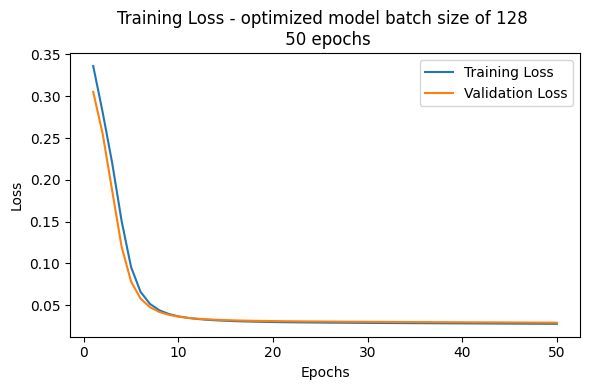

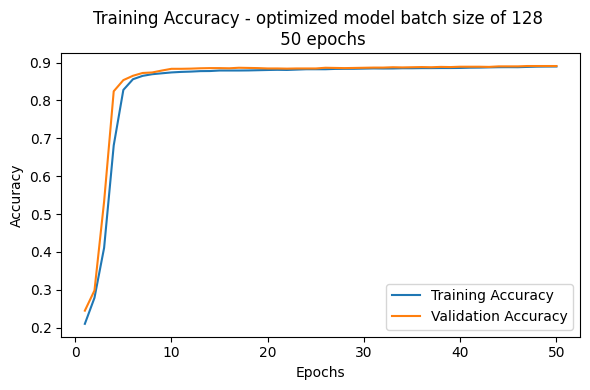

In [139]:
plot_history(history_batch, "optimized model batch size of 128 \n 50 epochs")

## reducing epochs and setting learning rate

In [140]:
model = keras.Sequential(
  [
    keras.Input(shape=(16,), name="input"),
    keras.layers.Dense(64, activation="relu",
                       name="hidden_layer_1"),
    keras.layers.Dense(16, activation="relu",
                       name="hidden_layer_2"),
    keras.layers.Dense(7, activation='softmax',
                       name="output")
  ]
)

model.build()

model.compile(
  optimizer=keras.optimizers.Adam(learning_rate=0.0012),
  loss=keras.losses.CategoricalFocalCrossentropy(),
  metrics=[keras.metrics.CategoricalAccuracy()]
)

model.summary()
history_epoch = model.fit(x_train, y_train, epochs=17, batch_size=128, validation_data=(x_val, y_val))

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 7)              │           119 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,247 (8.78 KB)

 Trainable params: 2,247 (8.78 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/17
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - categorical_accuracy: 0.2436 - loss: 0.3380 - val_categorical_accuracy: 0.2452 - val_loss: 0.3005
Epoch 2/17
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - categorical_accuracy: 0.2848 - loss: 0.2809 - val_categorical_accuracy: 0.4096 - val_loss: 0.2280
Epoch 3/17
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - categorical_accuracy: 0.5533 - loss: 0.2011 - val_categorical_accuracy: 0.7833 - val_loss: 0.1401
Epoch 4/17
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - categorical_accuracy: 0.7775 - loss: 0.1204 - val_categorical_accuracy: 0.8127 - val_loss: 0.0860
Epoch 5/17
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - categorical_accuracy: 0.8176 - loss: 0.0756 - val_categorical_accuracy: 0.8356 - val_loss: 0.0605
Epoch 6/17
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - categorical_accuracy: 0.8447 - loss: 0.0550 - val_categorical_accuracy: 0.8595 - val_loss: 0.0479
Epoch 7/17
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - categorical_accuracy: 0.8641 - loss: 0.0447 - va

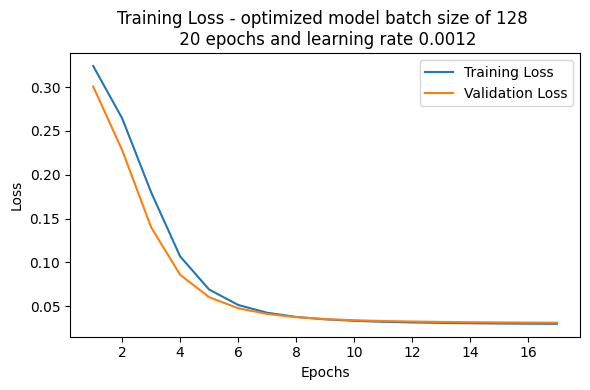

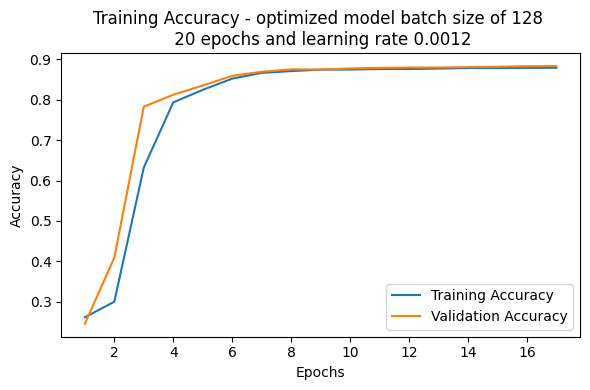

In [141]:
plot_history(history_epoch, "optimized model batch size of 128 \n 20 epochs and learning rate 0.0012")

# Training the final model

In [142]:
model = keras.Sequential(
  [
    keras.Input(shape=(16,), name="input"),
    keras.layers.Dense(64, activation="relu",
                       name="hidden_layer_1"),
    keras.layers.Dense(16, activation="relu",
                       name="hidden_layer_2"),
    keras.layers.Dense(7, activation='softmax',
                       name="output")
  ]
)

model.build()

model.compile(
  optimizer=keras.optimizers.Adam(learning_rate=0.0012),
  loss=keras.losses.CategoricalFocalCrossentropy(),
  metrics=[keras.metrics.CategoricalAccuracy()]
)

model.summary()
history_final = model.fit(pd.concat([x_train, x_val]), np.concatenate([y_train, y_val]), epochs=20, batch_size=128)

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 7)              │           119 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,247 (8.78 KB)

 Trainable params: 2,247 (8.78 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - categorical_accuracy: 0.2535 - loss: 0.3315
Epoch 2/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - categorical_accuracy: 0.4356 - loss: 0.2446
Epoch 3/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - categorical_accuracy: 0.7520 - loss: 0.1258
Epoch 4/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - categorical_accuracy: 0.8598 - loss: 0.0637
Epoch 5/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - categorical_accuracy: 0.8653 - loss: 0.0446
Epoch 6/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - categorical_accuracy: 0.8704 - loss: 0.0374
Epoch 7/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - categorical_accuracy: 0.8742 - loss: 0.0341
Epoch 8/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - categorical_accuracy: 0.8765 - loss: 0.0322
Epoch 9/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - categorical_accuracy: 0.8779 - loss: 0.0311
Epoch 10/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - categorical_accuracy: 0.8796 - loss: 0.0303
Epoch 11/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 

86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


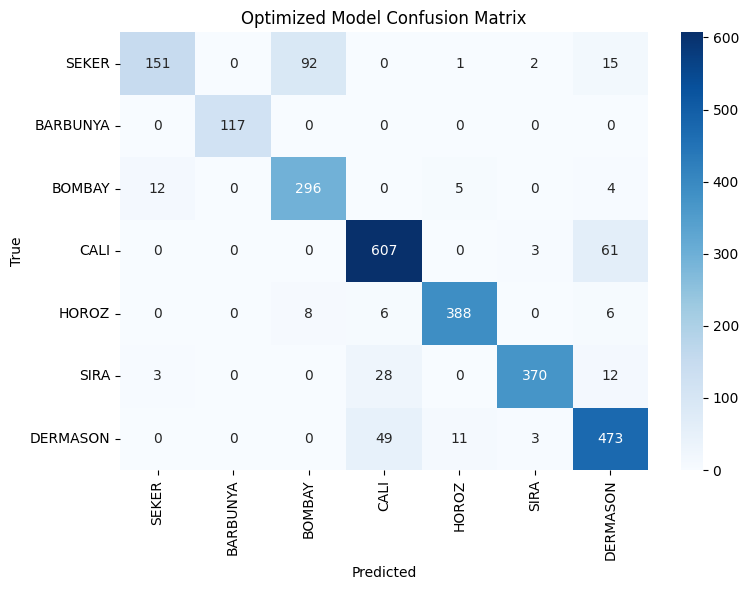

In [143]:
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# generate confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Optimized Model Confusion Matrix')
plt.xticks(rotation=90)

plt.tight_layout()
#plt.savefig('optimized_model_confusion_matrix.png')
#files.download('optimized_model_confusion_matrix.png')

plt.show()

In [144]:
# generate classification report
report = classification_report(y_true_classes, y_pred_classes)

print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.58      0.71       261
           1       1.00      1.00      1.00       117
           2       0.75      0.93      0.83       317
           3       0.88      0.90      0.89       671
           4       0.96      0.95      0.95       408
           5       0.98      0.90      0.94       413
           6       0.83      0.88      0.85       536

    accuracy                           0.88      2723
   macro avg       0.90      0.88      0.88      2723
weighted avg       0.89      0.88      0.88      2723



# models comparison

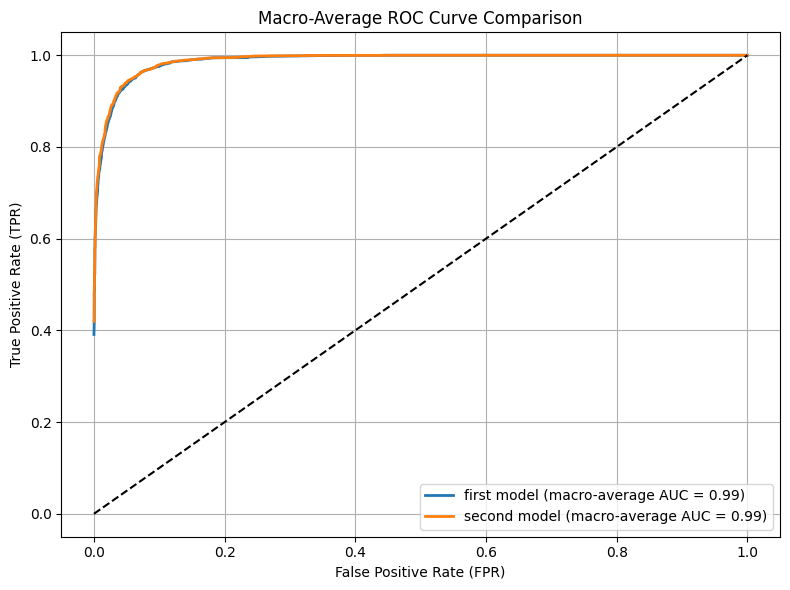

In [145]:
# roc for every class
n_classes = y_test.shape[1]
fpr1, tpr1, roc_auc1 = {}, {}, {}
fpr2, tpr2, roc_auc2 = {}, {}, {}

for i in range(n_classes):
    fpr1[i], tpr1[i], _ = roc_curve(y_test[:, i], y_pred_initial[:, i])
    fpr2[i], tpr2[i], _ = roc_curve(y_test[:, i], y_pred[:, i])
    roc_auc1[i] = auc(fpr1[i], tpr1[i])
    roc_auc2[i] = auc(fpr2[i], tpr2[i])

# macro avg
# fpr for all classes
all_fpr1 = np.unique(np.concatenate([fpr1[i] for i in range(n_classes)]))
all_fpr2 = np.unique(np.concatenate([fpr2[i] for i in range(n_classes)]))

# roc curve interpolation
mean_tpr1 = np.zeros_like(all_fpr1)
mean_tpr2 = np.zeros_like(all_fpr2)

for i in range(n_classes):
    mean_tpr1 += np.interp(all_fpr1, fpr1[i], tpr1[i])
    mean_tpr2 += np.interp(all_fpr2, fpr2[i], tpr2[i])

# tpr mean
mean_tpr1 /= n_classes
mean_tpr2 /= n_classes

# save results
fpr1["macro"] = all_fpr1
tpr1["macro"] = mean_tpr1
roc_auc1["macro"] = auc(fpr1["macro"], tpr1["macro"]) # auc model 1

fpr2["macro"] = all_fpr2
tpr2["macro"] = mean_tpr2
roc_auc2["macro"] = auc(fpr2["macro"], tpr2["macro"]) # auc model 2


# plot
plt.figure(figsize=(8, 6))

plt.plot(fpr1["macro"], tpr1["macro"],
         label=f'first model (macro-average AUC = {roc_auc1["macro"]:.2f})',
         linewidth=2)
plt.plot(fpr2["macro"], tpr2["macro"],
         label=f'second model (macro-average AUC = {roc_auc2["macro"]:.2f})',
         linewidth=2)

# reference line
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Macro-Average ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)

plt.tight_layout()

#plt.savefig('roc.png')
#files.download('roc.png')

plt.show()